# V8 corrigée

Correction globale par rapport à la V7 :

```text
build_results_dataframe est défini
compute_metrics ne bloque plus si AUPIMO n est pas calculable
run_ensemble_category sauvegarde au moins les métriques Dinomaly même si PatchCore ou ensemble échoue
diagnostic labels et masques ajouté
reprise depuis CSV conservée
AUPIMO méthode Natyprécédente conservée : (1e-5, 1e-2)
```


## 1. Imports et configuration

In [2]:
import gc
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.transform import resize as sk_resize
from sklearn.metrics import roc_auc_score
from torchvision import models, transforms
from torchvision.transforms import v2 as T

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA, EDA, PATHS

warnings.filterwarnings("ignore")
sns.set_theme(style=EDA.sns_style, palette=EDA.sns_palette, font_scale=EDA.sns_font_scale)
plt.rcParams["figure.dpi"] = EDA.figure_dpi
torch.set_float32_matmul_precision("medium")

from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.models import Dinomaly
from anomalib.pre_processing import PreProcessor
from anomalib.metrics.pimo.pimo import _AUPIMO

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
print("DEVICE :", DEVICE)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("PATHS.root :", PATHS.root)
print("PATHS.mvtec_dir :", PATHS.mvtec_dir)


Torch : 2.6.0+cu124
CUDA : True
DEVICE : cuda
PROJECT_ROOT : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus
PATHS.root : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus
PATHS.mvtec_dir : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/data/raw/mvtec


In [3]:
MVTEC_CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper",
]

# Configuration Missi originale
DINO_IMG_SIZE = 504
DINO_MAX_EPOCHS = 40
DINO_BATCH = 4
ENCODER = "dinov2reg_vit_base_14"

PC_IMG_SIZE = 256
PC_CORESET_RATIO = 0.1
PC_SMOOTH_SIGMA = 4.0
PC_BATCH = 8

# Notre calcul AUPIMO
NATY_AUPIMO_FPR_BOUNDS = (1e-5, 1e-2)

# Important :
# Si un checkpoint Missi existe, on le réutilise.
# S il n existe pas, on entraîne Dinomaly pour la catégorie puis on sauvegarde le checkpoint.
TRAIN_MISSING_DINO_CHECKPOINTS = True

OUTPUT_DIR = PATHS.root / "results" / "ensemble_all_naty_recalc"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DINO_CKPT_DIR = PATHS.root / "models" / "missi_dinomaly_recomputed"
DINO_CKPT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUTPUT_DIR / "missi_recalc_aupimo_naty_method_results.csv"
AUPIMO_CSV = OUTPUT_DIR / "missi_recalc_aupimo_naty_method_aupimo.csv"
REPORT_CSV = PATHS.root / "reports" / "mvtec_dinomaly_patchcore_ensemble_recalc_aupimo_naty_method.csv"
REPORT_CSV.parent.mkdir(parents=True, exist_ok=True)

DINO_CHECKPOINT_SEARCH_DIRS = [
    PATHS.root / "models",
    PATHS.root / "models" / "missi_dinomaly_recomputed",
    PATHS.root / "notebooks" / "results",
    PATHS.root / "results",
]

print("Catégories :", len(MVTEC_CATEGORIES))
print("OUTPUT_DIR :", OUTPUT_DIR)
print("DINO_CKPT_DIR :", DINO_CKPT_DIR)
print("AUPIMO bounds :", NATY_AUPIMO_FPR_BOUNDS)
print("Train missing Dinomaly checkpoints :", TRAIN_MISSING_DINO_CHECKPOINTS)


Catégories : 15
OUTPUT_DIR : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/results/ensemble_all_naty_recalc
DINO_CKPT_DIR : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/models/missi_dinomaly_recomputed
AUPIMO bounds : (1e-05, 0.01)
Train missing Dinomaly checkpoints : True


## 2. Fonctions utilitaires

In [4]:
def cleanup():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def normalize_result_columns(df):
    rename_map = {
        "dino_auc_img": "dino_img",
        "dino_auc_pix": "dino_pix",
        "dino_auc_pixel": "dino_pix",
        "patchcore_img": "pc_img",
        "patchcore_pix": "pc_pix",
        "patchcore_aupimo": "pc_aupimo",
        "ensemble_mean_img": "mean_img",
        "ensemble_mean_pix": "mean_pix",
        "ensemble_mean_aupimo": "mean_aupimo",
        "ensemble_max_img": "max_img",
        "ensemble_max_pix": "max_pix",
        "ensemble_max_aupimo": "max_aupimo",
    }
    df = df.rename(columns=rename_map)

    for col in df.columns:
        if col not in {"category", "n_test"} and pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].round(4)

    return df


def load_saved_results():
    if RESULTS_CSV.exists():
        print("Chargement résultats existants :", RESULTS_CSV)
        return normalize_result_columns(pd.read_csv(RESULTS_CSV))

    return pd.DataFrame()


def save_results(df):
    df = normalize_result_columns(df)
    df.to_csv(RESULTS_CSV, index=False)
    df.to_csv(REPORT_CSV, index=False)

    needed = ["category", "dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo"]

    if all(col in df.columns for col in needed):
        df_aupimo = df[needed].copy()
        df_aupimo["best"] = df_aupimo[["dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo"]].idxmax(axis=1)
        df_aupimo["Delta Mean - Dino"] = (df_aupimo["mean_aupimo"] - df_aupimo["dino_aupimo"]).round(3)
        df_aupimo = df_aupimo.sort_values("dino_aupimo")
        df_aupimo.to_csv(AUPIMO_CSV, index=False)

    print("Saved:", RESULTS_CSV)
    print("Saved:", REPORT_CSV)
    return df




def build_results_dataframe(all_results_obj=None):
    if all_results_obj is not None and len(all_results_obj) > 0:
        return normalize_result_columns(pd.DataFrame(all_results_obj))

    return load_saved_results()

def required_columns_available(df, cols, label):
    missing = [col for col in cols if col not in df.columns]

    if missing:
        print("Colonnes manquantes pour", label, ":", missing)
        print("Colonnes disponibles :", df.columns.tolist())
        return False

    return True


## 3. Checkpoints Dinomaly adaptés Cube AI

In [5]:
def expected_dino_checkpoint_name(category):
    return f"dinomaly_{category}_v2_{DINO_IMG_SIZE}_{DINO_MAX_EPOCHS}ep.ckpt"


def expected_dino_checkpoint_path(category):
    return DINO_CKPT_DIR / expected_dino_checkpoint_name(category)


def checkpoint_search_dirs():
    dirs = []

    for folder in DINO_CHECKPOINT_SEARCH_DIRS:
        folder = Path(folder)

        if folder.exists():
            dirs.append(folder)

    return dirs


def list_candidate_checkpoints(category):
    expected_name = expected_dino_checkpoint_name(category)

    patterns = [
        expected_name,
        f"*dinomaly*{category}*{DINO_IMG_SIZE}*{DINO_MAX_EPOCHS}*ep*.ckpt",
        f"*dinomaly*{category}*.ckpt",
        f"*{category}*.ckpt",
    ]

    candidates = []
    seen = set()

    for folder in checkpoint_search_dirs():
        for pattern in patterns:
            for path in folder.rglob(pattern):
                path = path.resolve()

                if path in seen:
                    continue

                seen.add(path)
                candidates.append(path)

    candidates = sorted(
        candidates,
        key=lambda p: (
            0 if p.name == expected_name else 1,
            0 if "missi_dinomaly_recomputed" in str(p) else 1,
            len(str(p)),
            -p.stat().st_mtime,
        ),
    )

    return candidates


def find_dinomaly_checkpoint(category):
    candidates = list_candidate_checkpoints(category)

    if len(candidates) == 0:
        return None

    return candidates[0]


def build_checkpoint_index():
    rows = []

    for category in MVTEC_CATEGORIES:
        candidates = list_candidate_checkpoints(category)

        rows.append({
            "category": category,
            "found": len(candidates) > 0,
            "selected_checkpoint": str(candidates[0]) if len(candidates) > 0 else "",
            "n_candidates": len(candidates),
            "expected_output": str(expected_dino_checkpoint_path(category)),
        })

    return pd.DataFrame(rows)


def show_checkpoint_index():
    ckpt_index_df = build_checkpoint_index()
    display(ckpt_index_df)
    return ckpt_index_df


ckpt_index_df = show_checkpoint_index()


,category,found,selected_checkpoint,n_candidates,expected_output
0,bottle,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
1,cable,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
2,capsule,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
3,carpet,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
4,grid,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
5,hazelnut,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
6,leather,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
7,metal_nut,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
8,pill,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...
9,screw,True,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...,1,/mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_in...


## 4. Métriques AUPIMO méthode Naty

In [6]:
def compute_metrics(heatmaps, gt_masks, labels):
    labels = np.asarray(labels).astype(int)
    gt_masks = np.asarray(gt_masks)
    heatmaps = np.asarray(heatmaps)

    img_scores = heatmaps.reshape(heatmaps.shape[0], -1).max(axis=1)

    if len(np.unique(labels)) >= 2:
        auc_img = roc_auc_score(labels, img_scores)
    else:
        auc_img = np.nan

    is_anom = labels == 1

    if is_anom.sum() > 0 and len(np.unique(gt_masks[is_anom].flatten())) >= 2:
        auc_pix = roc_auc_score(
            gt_masks[is_anom].flatten(),
            heatmaps[is_anom].flatten(),
        )
    else:
        auc_pix = np.nan

    aupimo = np.nan

    try:
        if gt_masks.sum() > 0:
            metric = _AUPIMO(
                fpr_bounds=NATY_AUPIMO_FPR_BOUNDS,
                return_average=False,
                force=True,
            )
            metric.update(
                torch.from_numpy(heatmaps).float(),
                torch.from_numpy(gt_masks).long(),
            )
            _, ar = metric.compute()

            aupimos = ar.aupimos
            valid = ~torch.isnan(aupimos)

            if valid.any():
                aupimo = aupimos[valid].mean().item()
    except Exception as error:
        print("AUPIMO non calculable pour ce bloc :", type(error).__name__, error)
        aupimo = np.nan

    return {
        "auc_img": auc_img,
        "auc_pix": auc_pix,
        "aupimo": aupimo,
        "aupimo_fpr_lower": NATY_AUPIMO_FPR_BOUNDS[0],
        "aupimo_fpr_upper": NATY_AUPIMO_FPR_BOUNDS[1],
    }


def collect_dino(predictions):
    heatmaps = []
    gt_masks = []
    labels = []
    paths = []

    for batch in predictions:
        h = batch.anomaly_map.detach().cpu().numpy()

        if h.ndim == 4:
            h = h.squeeze(1)

        heatmaps.append(h)

        gm = batch.gt_mask.detach().cpu().numpy()

        if gm.ndim == 4:
            gm = gm.squeeze(1)

        gt_masks.append(gm.astype(np.float32))
        labels.append(batch.gt_label.detach().cpu().numpy().astype(int))
        paths.extend(batch.image_path)

    return (
        np.concatenate(heatmaps),
        np.concatenate(gt_masks),
        np.concatenate(labels),
        [str(p) for p in paths],
    )


def norm_global(h):
    mn = float(h.min())
    mx = float(h.max())
    return ((h - mn) / (mx - mn + 1e-8)).astype(np.float32)


## 5. Dinomaly : entraînement si checkpoint absent, puis inference

In [7]:
def build_dinomaly_model():
    dino_pp = PreProcessor(transform=T.Compose([
        T.Resize(
            (DINO_IMG_SIZE, DINO_IMG_SIZE),
            interpolation=T.InterpolationMode.BILINEAR,
            antialias=True,
        ),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]))

    model = Dinomaly(
        encoder_name=ENCODER,
        bottleneck_dropout=0.2,
        decoder_depth=8,
        pre_processor=dino_pp,
    )

    return model


def build_mvtec_datamodule(category):
    dm = MVTecAD(
        root=PATHS.mvtec_dir,
        category=category,
        train_batch_size=DINO_BATCH,
        eval_batch_size=DINO_BATCH,
        num_workers=0,
        seed=DATA.random_seed,
    )
    dm.setup()
    return dm


def load_dinomaly_state_dict(model, ckpt_path):
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    except Exception:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    if not isinstance(state_dict, dict):
        raise TypeError(f"Checkpoint non compatible : {ckpt_path}")

    attempts = [("raw", state_dict)]

    stripped_model = {}

    for key, value in state_dict.items():
        new_key = key[len("model."):] if key.startswith("model.") else key
        stripped_model[new_key] = value

    attempts.append(("strip_model_prefix", stripped_model))

    best_error = None

    for name, candidate in attempts:
        try:
            missing, unexpected = model.load_state_dict(candidate, strict=False)
            print("Checkpoint chargé avec stratégie :", name)
            print("Missing keys :", len(missing))
            print("Unexpected keys :", len(unexpected))
            return model
        except Exception as error:
            best_error = error

    raise RuntimeError(f"Impossible de charger le checkpoint {ckpt_path}: {best_error}")


def ensure_dino_checkpoint(category):
    existing = find_dinomaly_checkpoint(category)

    if existing is not None:
        print("Checkpoint existant trouvé :", existing)
        return existing

    if not TRAIN_MISSING_DINO_CHECKPOINTS:
        print("Checkpoint absent et entraînement désactivé :", category)
        return None

    print("Aucun checkpoint trouvé. Entraînement Dinomaly pour :", category)

    cleanup()
    dm = build_mvtec_datamodule(category)
    model = build_dinomaly_model()

    train_root = OUTPUT_DIR / "dinomaly_training" / category
    train_root.mkdir(parents=True, exist_ok=True)

    engine = Engine(
        max_epochs=DINO_MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        default_root_dir=str(train_root),
        logger=False,
    )

    engine.fit(model=model, datamodule=dm)

    out_ckpt = expected_dino_checkpoint_path(category)
    torch.save(model.state_dict(), out_ckpt)

    print("Checkpoint Dinomaly sauvegardé :", out_ckpt)

    del model, engine, dm
    cleanup()

    return out_ckpt


def predict_dinomaly(category):
    ckpt_path = ensure_dino_checkpoint(category)

    if ckpt_path is None:
        return None

    dm = build_mvtec_datamodule(category)
    model = build_dinomaly_model()
    model = load_dinomaly_state_dict(model, ckpt_path)

    engine = Engine(
        max_epochs=DINO_MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        default_root_dir=str(OUTPUT_DIR / "dinomaly_predict"),
        logger=False,
    )

    preds = engine.predict(model=model, datamodule=dm)
    heatmaps_dino, gt_masks_dino, labels, paths = collect_dino(preds)

    train_paths = [str(item.image_path) for item in dm.train_data]

    del model, engine, preds, dm
    cleanup()

    return heatmaps_dino, gt_masks_dino, labels, paths, train_paths


## 6. PatchCore manuel

In [8]:
tf_img_pc = transforms.Compose([
    transforms.Resize(
        (PC_IMG_SIZE, PC_IMG_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

tf_mask_pc = transforms.Compose([
    transforms.Resize(
        (PC_IMG_SIZE, PC_IMG_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST,
    ),
    transforms.PILToTensor(),
])


def _load_img_pc(p):
    return tf_img_pc(Image.open(p).convert("RGB"))


def _build_pc_backbone():
    bb = models.wide_resnet50_2(
        weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1,
    )
    bb.eval()

    for p in bb.parameters():
        p.requires_grad = False

    bb = bb.to(DEVICE)
    feats = {}

    def hook(name):
        def fn(_m, _i, out):
            feats[name] = out
        return fn

    bb.layer2.register_forward_hook(hook("layer2"))
    bb.layer3.register_forward_hook(hook("layer3"))

    return bb, feats


def _extract_feat_pc(bb, feats_cache, batch_tensor):
    feats_cache.clear()

    with torch.no_grad():
        _ = bb(batch_tensor.to(DEVICE))

    f2 = feats_cache["layer2"]
    f3 = feats_cache["layer3"]

    f2 = F.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
    f3 = F.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
    f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)

    return torch.cat([f2, f3], dim=1)


def gt_from_path(test_path):
    p = Path(test_path)

    if "good" in p.parts:
        return np.zeros((PC_IMG_SIZE, PC_IMG_SIZE), dtype=np.float32)

    defect = p.parent.name
    category = p.parents[1].name
    mask_name = p.stem + "_mask.png"
    mask_path = PATHS.mvtec_dir / category / "ground_truth" / defect / mask_name

    if not mask_path.exists():
        return np.zeros((PC_IMG_SIZE, PC_IMG_SIZE), dtype=np.float32)

    mask = Image.open(mask_path).convert("L")
    mask = tf_mask_pc(mask).squeeze(0).numpy()
    mask = (mask > 0).astype(np.float32)

    return mask


def run_patchcore(train_paths, test_paths):
    bb, feats_cache = _build_pc_backbone()

    all_patches = []

    for i in range(0, len(train_paths), PC_BATCH):
        chunk = train_paths[i:i + PC_BATCH]
        imgs = torch.stack([_load_img_pc(p) for p in chunk])
        feat = _extract_feat_pc(bb, feats_cache, imgs)
        b, d, h, w = feat.shape
        all_patches.append(feat.permute(0, 2, 3, 1).reshape(-1, d).cpu())

    memory_bank = torch.cat(all_patches, dim=0)

    torch.manual_seed(DATA.random_seed)
    n_coreset = max(1, int(len(memory_bank) * PC_CORESET_RATIO))
    idx = torch.randperm(len(memory_bank))[:n_coreset]
    coreset = memory_bank[idx].to(DEVICE)

    heatmaps_pc = []
    gt_masks_pc = []

    for i in range(0, len(test_paths), PC_BATCH):
        chunk = test_paths[i:i + PC_BATCH]
        imgs = torch.stack([_load_img_pc(p) for p in chunk])
        feat = _extract_feat_pc(bb, feats_cache, imgs)
        b, d, hf, wf = feat.shape

        patches = feat.permute(0, 2, 3, 1).reshape(-1, d)
        dists = torch.cdist(patches, coreset)
        nn_dist, _ = dists.min(dim=1)
        nn_dist = nn_dist.reshape(b, hf, wf).cpu().numpy()

        for j in range(b):
            h_img = Image.fromarray(nn_dist[j].astype(np.float32))
            h = np.array(h_img.resize((PC_IMG_SIZE, PC_IMG_SIZE), Image.BILINEAR))
            h = gaussian_filter(h, sigma=PC_SMOOTH_SIGMA)
            heatmaps_pc.append(h)

        for p in chunk:
            gt_masks_pc.append(gt_from_path(p))

    del bb, memory_bank, coreset
    cleanup()

    return np.stack(heatmaps_pc), np.stack(gt_masks_pc)


## 7. Pipeline par catégorie

In [9]:
def run_ensemble_category(category):
    print()
    print("=" * 70)
    print("Catégorie :", category)
    print("=" * 70)

    t0 = time.time()

    pred = predict_dinomaly(category)

    if pred is None:
        print("Dinomaly impossible pour :", category)
        return None

    heatmaps_dino, gt_masks_dino, labels, paths, train_paths = pred

    print("Dinomaly inference OK :", len(paths), "images")
    print("Labels uniques :", np.unique(labels, return_counts=True))
    print("Somme masques GT :", float(np.asarray(gt_masks_dino).sum()))

    metrics_dino = compute_metrics(heatmaps_dino, gt_masks_dino, labels)

    print(
        "Dinomaly seul :",
        "img =", round(metrics_dino["auc_img"], 4) if not np.isnan(metrics_dino["auc_img"]) else np.nan,
        "pix =", round(metrics_dino["auc_pix"], 4) if not np.isnan(metrics_dino["auc_pix"]) else np.nan,
        "AUPIMO =", round(metrics_dino["aupimo"], 4) if not np.isnan(metrics_dino["aupimo"]) else np.nan,
    )

    metrics_pc = {"auc_img": np.nan, "auc_pix": np.nan, "aupimo": np.nan}
    metrics_mean = {"auc_img": np.nan, "auc_pix": np.nan, "aupimo": np.nan}
    metrics_max = {"auc_img": np.nan, "auc_pix": np.nan, "aupimo": np.nan}

    try:
        heatmaps_pc, gt_masks_pc = run_patchcore(train_paths, paths)
        metrics_pc = compute_metrics(heatmaps_pc, gt_masks_pc, labels)

        print(
            "PatchCore seul :",
            "img =", round(metrics_pc["auc_img"], 4) if not np.isnan(metrics_pc["auc_img"]) else np.nan,
            "pix =", round(metrics_pc["auc_pix"], 4) if not np.isnan(metrics_pc["auc_pix"]) else np.nan,
            "AUPIMO =", round(metrics_pc["aupimo"], 4) if not np.isnan(metrics_pc["aupimo"]) else np.nan,
        )

        target_shape = heatmaps_dino.shape[1:]

        if heatmaps_pc.shape[1:] != target_shape:
            heatmaps_pc_aligned = np.stack([
                sk_resize(h, target_shape, order=1, preserve_range=True, anti_aliasing=True)
                for h in heatmaps_pc
            ]).astype(np.float32)
        else:
            heatmaps_pc_aligned = heatmaps_pc.copy()

        heatmaps_dino_n = norm_global(heatmaps_dino)
        heatmaps_pc_n = norm_global(heatmaps_pc_aligned)

        ens_mean = (heatmaps_dino_n + heatmaps_pc_n) / 2
        ens_max = np.maximum(heatmaps_dino_n, heatmaps_pc_n)

        metrics_mean = compute_metrics(ens_mean, gt_masks_dino, labels)
        metrics_max = compute_metrics(ens_max, gt_masks_dino, labels)

        print(
            "Ensemble Mean :",
            "img =", round(metrics_mean["auc_img"], 4) if not np.isnan(metrics_mean["auc_img"]) else np.nan,
            "pix =", round(metrics_mean["auc_pix"], 4) if not np.isnan(metrics_mean["auc_pix"]) else np.nan,
            "AUPIMO =", round(metrics_mean["aupimo"], 4) if not np.isnan(metrics_mean["aupimo"]) else np.nan,
        )
        print(
            "Ensemble Max :",
            "img =", round(metrics_max["auc_img"], 4) if not np.isnan(metrics_max["auc_img"]) else np.nan,
            "pix =", round(metrics_max["auc_pix"], 4) if not np.isnan(metrics_max["auc_pix"]) else np.nan,
            "AUPIMO =", round(metrics_max["aupimo"], 4) if not np.isnan(metrics_max["aupimo"]) else np.nan,
        )

        del heatmaps_pc, heatmaps_dino_n, heatmaps_pc_n, heatmaps_pc_aligned, ens_mean, ens_max

    except Exception as error:
        print("PatchCore ou ensemble non calculable pour", category, ":", type(error).__name__, error)

    del heatmaps_dino
    cleanup()

    return {
        "category": category,
        "n_test": len(paths),
        "dino_img": metrics_dino["auc_img"],
        "dino_pix": metrics_dino["auc_pix"],
        "dino_aupimo": metrics_dino["aupimo"],
        "pc_img": metrics_pc["auc_img"],
        "pc_pix": metrics_pc["auc_pix"],
        "pc_aupimo": metrics_pc["aupimo"],
        "mean_img": metrics_mean["auc_img"],
        "mean_pix": metrics_mean["auc_pix"],
        "mean_aupimo": metrics_mean["aupimo"],
        "max_img": metrics_max["auc_img"],
        "max_pix": metrics_max["auc_pix"],
        "max_aupimo": metrics_max["aupimo"],
        "aupimo_fpr_lower": NATY_AUPIMO_FPR_BOUNDS[0],
        "aupimo_fpr_upper": NATY_AUPIMO_FPR_BOUNDS[1],
        "duration_min": round((time.time() - t0) / 60, 2),
    }


print("Pipeline prêt")


Pipeline prêt


## 8. Boucle sur les catégories

In [10]:
saved_df = load_saved_results()

if not saved_df.empty and "category" in saved_df.columns:
    already_done = set(saved_df["category"].astype(str))
else:
    already_done = set()

all_results = []

if not saved_df.empty:
    all_results.extend(saved_df.to_dict("records"))

print("Catégories déjà calculées :", sorted(already_done))

t_total = time.time()

for category in MVTEC_CATEGORIES:
    if category in already_done:
        print("Déjà calculé, skip :", category)
        continue

    try:
        result = run_ensemble_category(category)

        if result is not None:
            all_results.append(result)
            df_current = save_results(pd.DataFrame(all_results))
            print("Résultat sauvegardé après :", category)

    except Exception as error:
        print("Erreur sur", category, ":", type(error).__name__, error)

print()
print("=" * 70)
print("Total résultats :", len(all_results))
print("Durée totale min :", round((time.time() - t_total) / 60, 1))

df = build_results_dataframe(all_results)
display(df)


Catégories déjà calculées : []

Catégorie : bottle
Checkpoint existant trouvé : /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/models/missi_dinomaly_recomputed/dinomaly_bottle_v2_504_40ep.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
ckpt_path is not provided. Model weights will not be loaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Checkpoint chargé avec stratégie : raw
Missing keys : 0
Unexpected keys : 0


Output()

Dinomaly inference OK : 83 images
Labels uniques : (array([0, 1]), array([20, 63]))
Somme masques GT : 1219048.0


...

Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


Dinomaly seul : img = 0.9992 pix = 0.9894 AUPIMO = 0.8781
PatchCore seul : img = 0.9808 pix = nan AUPIMO = nan


Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


Ensemble Mean : img = 0.9971 pix = 0.9902 AUPIMO = 0.8453
Ensemble Max : img = 0.9942 pix = 0.9848 AUPIMO = 0.7113
Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/results/ensemble_all_naty_recalc/missi_recalc_aupimo_naty_method_results.csv
Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/reports/mvtec_dinomaly_patchcore_ensemble_recalc_aupimo_naty_method.csv
Résultat sauvegardé après : zipper

Total résultats : 15
Durée totale min : 100.3


,category,n_test,dino_img,dino_pix,dino_aupimo,pc_img,pc_pix,pc_aupimo,mean_img,mean_pix,mean_aupimo,max_img,max_pix,max_aupimo,aupimo_fpr_lower,aupimo_fpr_upper,duration_min
0,bottle,83,1.0000,0.9907,0.9729,1.0000,NaN,NaN,1.0000,0.9896,0.9902,1.0000,0.9838,0.9944,0.0,0.01,4.01
1,cable,150,0.9914,0.9834,0.8083,0.9923,NaN,NaN,0.9987,0.9861,0.9063,0.9925,0.9812,0.7729,0.0,0.01,8.73
2,capsule,132,0.9908,0.9874,0.8656,0.9653,NaN,NaN,1.0000,0.9927,0.9482,0.9988,0.9913,0.8934,0.0,0.01,7.86
3,carpet,117,0.9984,0.9925,0.9536,0.9884,NaN,NaN,1.0000,0.9931,0.9925,1.0000,0.9896,0.9608,0.0,0.01,7.01
4,grid,78,1.0000,0.9934,0.9992,0.9758,NaN,NaN,1.0000,0.9918,0.9961,0.9975,0.9872,0.8499,0.0,0.01,4.56
5,hazelnut,110,1.0000,0.9934,0.9675,1.0000,NaN,NaN,1.0000,0.9917,0.9857,1.0000,0.9820,0.9223,0.0,0.01,7.04
6,leather,124,1.0000,0.9922,0.9999,1.0000,NaN,NaN,1.0000,0.9924,1.0000,1.0000,0.9908,0.9996,0.0,0.01,7.43
7,metal_nut,115,1.0000,0.9749,0.9622,0.9971,NaN,NaN,1.0000,0.9839,0.9727,1.0000,0.9851,0.8479,0.0,0.01,6.37
8,pill,167,0.9894,0.9826,0.8845,0.9389,NaN,NaN,0.9869,0.9851,0.8994,0.9523,0.9756,0.5695,0.0,0.01,9.32
9,screw,160,0.9631,0.9965,0.8264,0.8678,NaN,NaN,0.9695,0.9956,0.8312,0.8813,0.9866,0.5434,0.0,0.01,9.24


## 9. Tableau de synthèse

In [11]:
df = build_results_dataframe(all_results if "all_results" in globals() else None)

if df.empty:
    print("Aucun résultat disponible.")
else:
    needed_aupimo = ["category", "dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo"]

    if required_columns_available(df, needed_aupimo, "AUPIMO"):
        df_aupimo = df[needed_aupimo].copy()
        df_aupimo["best"] = df_aupimo[["dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo"]].idxmax(axis=1)
        df_aupimo["Delta Mean - Dino"] = (df_aupimo["mean_aupimo"] - df_aupimo["dino_aupimo"]).round(3)
        df_aupimo = df_aupimo.sort_values("dino_aupimo")

        print("AUPIMO recalculé méthode Naty")
        print("AUPIMO_FPR_BOUNDS =", NATY_AUPIMO_FPR_BOUNDS)
        display(df_aupimo)

    needed_img = ["category", "dino_img", "pc_img", "mean_img", "max_img"]

    if required_columns_available(df, needed_img, "AUROC image"):
        df_img = df[needed_img].copy()
        df_img["Delta Mean - Dino"] = (df_img["mean_img"] - df_img["dino_img"]).round(4)
        df_img = df_img.sort_values("dino_img")
        display(df_img)

    print("Moyennes")
    for col_set, label in [
        (["dino_img", "pc_img", "mean_img", "max_img"], "AUROC image"),
        (["dino_pix", "pc_pix", "mean_pix", "max_pix"], "AUROC pixel"),
        (["dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo"], "AUPIMO"),
    ]:
        available = [c for c in col_set if c in df.columns]
        print(label)

        for c in available:
            print(f"  {c:<15} : {df[c].mean():.4f}")

    save_results(df)


AUPIMO recalculé méthode Naty
AUPIMO_FPR_BOUNDS = (1e-05, 0.01)


,category,dino_aupimo,pc_aupimo,mean_aupimo,max_aupimo,best,Delta Mean - Dino
12,transistor,0.4215,NaN,0.5938,0.6579,max_aupimo,0.172
11,toothbrush,0.6802,NaN,0.7693,0.7795,max_aupimo,0.089
13,wood,0.7510,NaN,0.8203,0.8018,mean_aupimo,0.069
1,cable,0.8083,NaN,0.9063,0.7729,mean_aupimo,0.098
9,screw,0.8264,NaN,0.8312,0.5434,mean_aupimo,0.005
2,capsule,0.8656,NaN,0.9482,0.8934,mean_aupimo,0.083
14,zipper,0.8781,NaN,0.8453,0.7113,dino_aupimo,-0.033
8,pill,0.8845,NaN,0.8994,0.5695,mean_aupimo,0.015
3,carpet,0.9536,NaN,0.9925,0.9608,mean_aupimo,0.039
7,metal_nut,0.9622,NaN,0.9727,0.8479,mean_aupimo,0.010


,category,dino_img,pc_img,mean_img,max_img,Delta Mean - Dino
9,screw,0.9631,0.8678,0.9695,0.8813,0.0064
11,toothbrush,0.9722,0.9583,0.9722,0.9750,0.0000
8,pill,0.9894,0.9389,0.9869,0.9523,-0.0025
2,capsule,0.9908,0.9653,1.0000,0.9988,0.0092
1,cable,0.9914,0.9923,0.9987,0.9925,0.0073
12,transistor,0.9925,0.9979,0.9996,0.9954,0.0071
13,wood,0.9956,0.9886,0.9965,0.9895,0.0009
3,carpet,0.9984,0.9884,1.0000,1.0000,0.0016
14,zipper,0.9992,0.9808,0.9971,0.9942,-0.0021
7,metal_nut,1.0000,0.9971,1.0000,1.0000,0.0000


Moyennes
AUROC image
  dino_img        : 0.9928
  pc_img          : 0.9767
  mean_img        : 0.9947
  max_img         : 0.9851
AUROC pixel
  dino_pix        : 0.9810
  pc_pix          : nan
  mean_pix        : 0.9841
  max_pix         : 0.9772
AUPIMO
  dino_aupimo     : 0.8639
  pc_aupimo       : nan
  mean_aupimo     : 0.9031
  max_aupimo      : 0.8164
Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/results/ensemble_all_naty_recalc/missi_recalc_aupimo_naty_method_results.csv
Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/reports/mvtec_dinomaly_patchcore_ensemble_recalc_aupimo_naty_method.csv


## 10. Figures

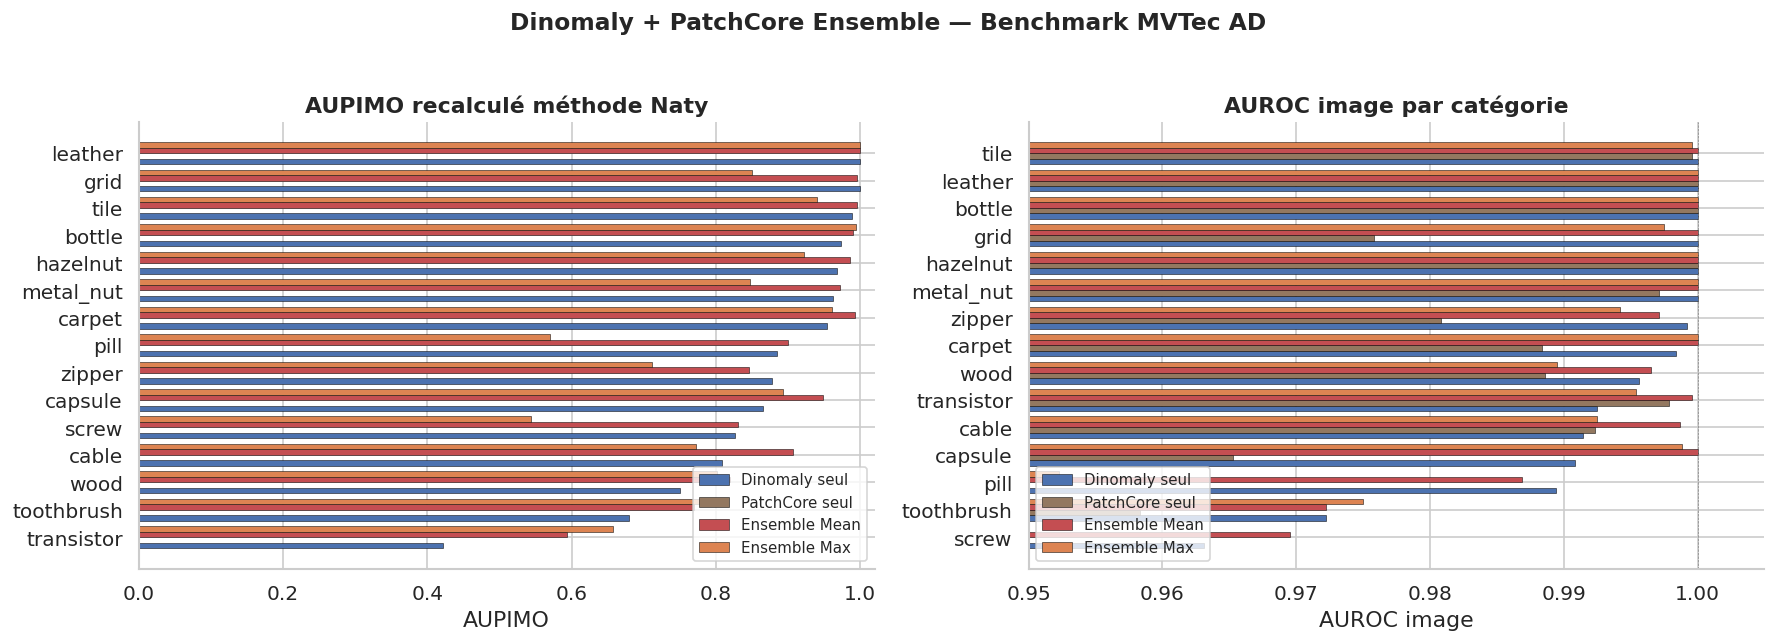

In [12]:
df = build_results_dataframe(all_results if "all_results" in globals() else None)

required_for_plot = [
    "category",
    "dino_aupimo", "pc_aupimo", "mean_aupimo", "max_aupimo",
    "dino_img", "pc_img", "mean_img", "max_img",
]

if df.empty:
    print("Aucune figure générée : aucun résultat disponible.")
elif not required_columns_available(df, required_for_plot, "figures"):
    print("Aucune figure générée : colonnes insuffisantes.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.35 * len(df))))

    df_sorted = df.sort_values("dino_aupimo")
    yp = np.arange(len(df_sorted))
    h = 0.2

    axes[0].barh(yp - 1.5*h, df_sorted["dino_aupimo"], height=h, label="Dinomaly seul",
                 color=EDA.color_mvtec, edgecolor="black", linewidth=0.3)
    axes[0].barh(yp - 0.5*h, df_sorted["pc_aupimo"], height=h, label="PatchCore seul",
                 color="#937860", edgecolor="black", linewidth=0.3)
    axes[0].barh(yp + 0.5*h, df_sorted["mean_aupimo"], height=h, label="Ensemble Mean",
                 color=EDA.color_anomal, edgecolor="black", linewidth=0.3)
    axes[0].barh(yp + 1.5*h, df_sorted["max_aupimo"], height=h, label="Ensemble Max",
                 color=EDA.color_hssiad, edgecolor="black", linewidth=0.3)
    axes[0].set_yticks(yp)
    axes[0].set_yticklabels(df_sorted["category"])
    axes[0].set_xlim(0, 1.02)
    axes[0].set_xlabel("AUPIMO")
    axes[0].set_title("AUPIMO recalculé méthode Naty", fontweight="bold")
    axes[0].legend(loc="lower right", fontsize=9)
    sns.despine(ax=axes[0])

    df_sorted2 = df.sort_values("dino_img")
    yp2 = np.arange(len(df_sorted2))

    axes[1].barh(yp2 - 1.5*h, df_sorted2["dino_img"], height=h, label="Dinomaly seul",
                 color=EDA.color_mvtec, edgecolor="black", linewidth=0.3)
    axes[1].barh(yp2 - 0.5*h, df_sorted2["pc_img"], height=h, label="PatchCore seul",
                 color="#937860", edgecolor="black", linewidth=0.3)
    axes[1].barh(yp2 + 0.5*h, df_sorted2["mean_img"], height=h, label="Ensemble Mean",
                 color=EDA.color_anomal, edgecolor="black", linewidth=0.3)
    axes[1].barh(yp2 + 1.5*h, df_sorted2["max_img"], height=h, label="Ensemble Max",
                 color=EDA.color_hssiad, edgecolor="black", linewidth=0.3)
    axes[1].set_yticks(yp2)
    axes[1].set_yticklabels(df_sorted2["category"])
    axes[1].set_xlim(0.95, 1.005)
    axes[1].axvline(1.0, color="gray", lw=0.4, ls="--")
    axes[1].set_xlabel("AUROC image")
    axes[1].set_title("AUROC image par catégorie", fontweight="bold")
    axes[1].legend(loc="lower left", fontsize=9)
    sns.despine(ax=axes[1])

    plt.suptitle("Dinomaly + PatchCore Ensemble — Benchmark MVTec AD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


## 11. Exports finaux

In [13]:
df = build_results_dataframe(all_results if "all_results" in globals() else None)

if df.empty:
    print("Aucun export final : aucun résultat disponible.")
else:
    save_results(df)
    print("Export final terminé.")


Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/results/ensemble_all_naty_recalc/missi_recalc_aupimo_naty_method_results.csv
Saved: /mnt/nvme/AI-Lab/mar26_bds_anomalies_pieces_indus/reports/mvtec_dinomaly_patchcore_ensemble_recalc_aupimo_naty_method.csv
Export final terminé.
